In [34]:
from alc import *
from imports import *
import torch
from torchvision.models import efficientnet_b3
from torchvision.models import EfficientNet_B3_Weights
from torchvision.io import read_image
import requests
import json
import os
import matplotlib.pyplot as plt

from labos.labo_01_fundamentos import transpuesta
from labos.labo_05_factorizacion_qr import calculaQR
from labos.labo_08_svd import svd_reducida


# Visualizacion de los datos de entrenamiento 

Clase predicha por el modelo para cat.7.jpg: Egyptian Mau
Clase predicha por el modelo para dog.4.jpg: English foxhound


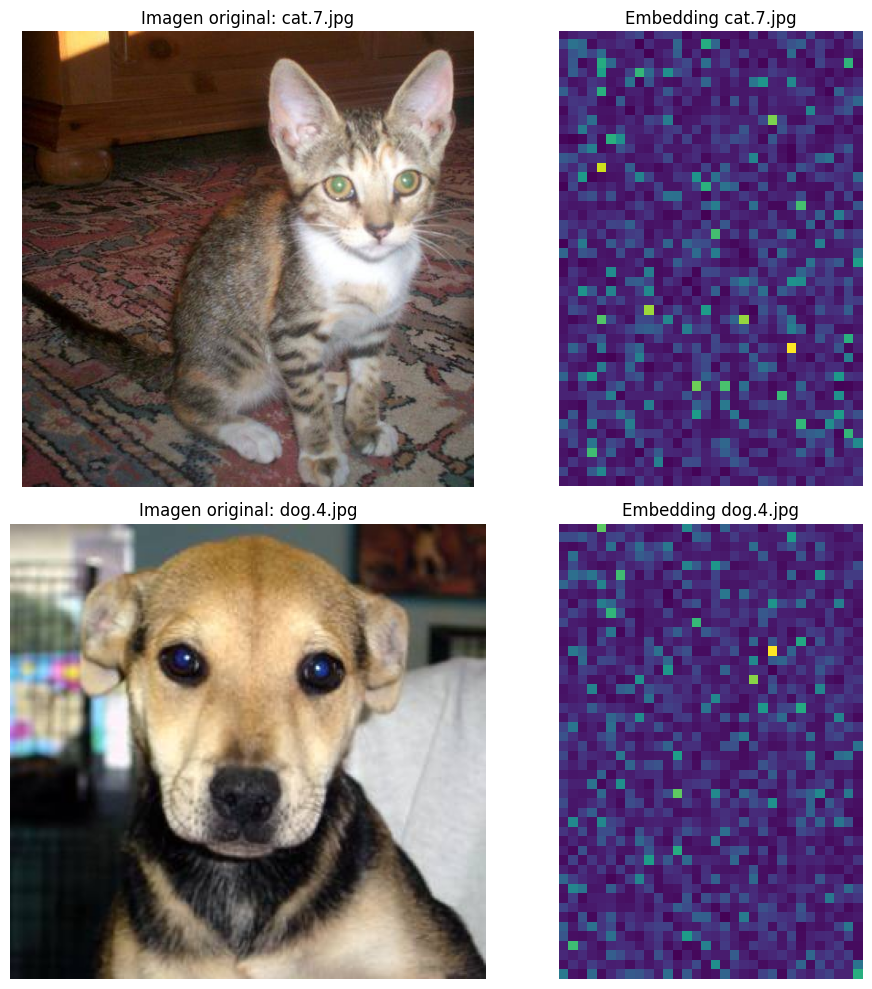

In [45]:
from ejemplo.obtener_embeddings import plot_images_and_embeddings

labels_url = ("https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json")
# Levantar el contenido de la url
response = requests.get(labels_url)
response.raise_for_status()  

# cargar el contenido como JSON
imagenet_labels = json.loads(response.text)

weights = EfficientNet_B3_Weights.DEFAULT
preprocess = weights.transforms()
model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
model.eval()
imagenes = ['cat.7.jpg', 'dog.4.jpg']

# Definir listas para reservar las imagenes, embedding y luego graficar
images_processed = []
embeddings = []
for imagen in imagenes:
    i = read_image(imagen)
    with torch.no_grad():
        # Aplicar la transformacion para preparar la imagen al formato que entiende el modelo
        processed_image = preprocess(i).unsqueeze(0)
        images_processed.append(i)

        i = preprocess(i).unsqueeze(0)
        # Obtener la salida del modelo con las probabilidades de cada clase de IMAGENET
        outputs = model(processed_image)
        # Identificar la clase con la maxima probabilidad
        _, predicted_idx = torch.max(outputs, 1)
        # Mostrar la etiqueta de la maxima probabilidad
        predicted_label = imagenet_labels[predicted_idx.item()]
        print(f"Clase predicha por el modelo para {imagen}: {predicted_label}")

        # Extraer los embeddings
        features = model.features(processed_image) # model.features sería la salida del Body
        pooled_features = model.avgpool(features) # paso anterior al fully connected que comprime el tamaño
        flattened = torch.flatten(pooled_features, 1).detach().cpu().numpy()
        embeddings.append(flattened[0])
plot_images_and_embeddings(images_processed, embeddings, imagenes)

[[1. 0.]
 [0. 1.]]


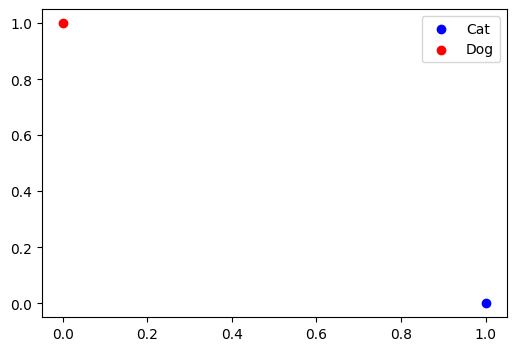

In [43]:
test_m = np.array(embeddings)
A = matmulti(test_m, transpuesta(test_m)) ## MAL
W = pinvEcuacionesNormales(A, np.array([[1,0],[0,1]]))
r = matmulti(W,A)
print(r)
labels = ['Cat', 'Dog']
colors = ['blue', 'red']
plt.figure(figsize=(6,4))
for i, label in enumerate(labels):
    plt.scatter(r[i,0], r[i,1], color=colors[i], label=label)


plt.legend()
plt.show()

In [9]:
actualPath = os.getcwd()
basePath = os.path.join(actualPath, "cats_and_dogs")
Xt, Yt, Xv, Yv = cargarDataset(basePath)
print("Tamano del dataset training X (Cat, Dog): ", Xt.shape)
print("Tamano del dataset training Y (Cat, Dog): ", Yt.shape)
print("Tamano del dataset verification X (Cat, Dog): ", Xv.shape)
print("Tamano del dataset verification Y (Cat, Dog): ", Yv.shape)

Tamano del dataset training X (Cat, Dog):  (1536, 2000)
Tamano del dataset training Y (Cat, Dog):  (2000, 2)
Tamano del dataset verification X (Cat, Dog):  (1536, 1000)
Tamano del dataset verification Y (Cat, Dog):  (1000, 2)


Divido los datos en 4-set tal que cada set tenga la misma cantidad de datos de perros como de gatos

In [16]:
import random
def random_k_samples(emb, res, k):
    X, Y = [], []
    aux = transpuesta(emb)
    idx = random.sample(range(emb.shape[1]), k) # Garantiza no repetidos
    for r in idx:
        X.append(aux[r])
        Y.append(res[r])
    return transpuesta(np.array(X)), np.array(Y)
        
X,Y = random_k_samples(Xt, Yt,10)
print(X.shape)
print(Y)

(1536, 10)
[[0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]]


## Cholesky

In [17]:
W = pinvEcuacionesNormales(X,transpuesta(Y))
r = transpuesta(matmulti(W, X))
print(r)

[[ 9.32088608e-16  1.00000000e+00]
 [ 1.68750647e-15  1.00000000e+00]
 [ 1.21361525e-15  1.00000000e+00]
 [ 1.00000000e+00  1.19262239e-17]
 [-1.89301699e-16  1.00000000e+00]
 [ 1.00000000e+00  1.87355556e-15]
 [-2.90132501e-16  1.00000000e+00]
 [ 1.00000000e+00 -1.07552856e-16]
 [ 1.00000000e+00  2.43593123e-16]
 [-7.32514093e-17  1.00000000e+00]]


## svd 

In [23]:
s, v, d = svd_reducida(X)
W  = pinvSVD(s,v,d,Y)
r = transpuesta(matmulti(W, X))
print(r)

[[ 9.32088608e-16  1.00000000e+00]
 [ 1.68750647e-15  1.00000000e+00]
 [ 1.21361525e-15  1.00000000e+00]
 [ 1.00000000e+00  1.19262239e-17]
 [-1.89301699e-16  1.00000000e+00]
 [ 1.00000000e+00  1.87355556e-15]
 [-2.90132501e-16  1.00000000e+00]
 [ 1.00000000e+00 -1.07552856e-16]
 [ 1.00000000e+00  2.43593123e-16]
 [-7.32514093e-17  1.00000000e+00]]


## QR

In [44]:
# HouseHolder
Q,R = calculaQR(transpuesta(Xt))
W = pinvHouseHolder(Q,R,Yt)
r = transpuesta(matmulti(W, X))
print(r)

KeyboardInterrupt: 

In [ ]:
Q,R = calculaQR(transpuesta(Xt),'GS')
W = pinvGramSchmidt(Q,R,Yt)
r = transpuesta(matmulti(W, X))
print(r)